In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
# Load main dataset
df = pd.read_csv(r"G:\663P\dataset\data\updated_dataset_2_metrics_f.csv")
# df = pd.read_csv(r"/Volumes/T7-Shield/663P/dataset/data/updated_dataset_metrics.csv")
# 1. DROP "NO DOC" ROWS: Remove NaNs and rows where doc_lines is 0
df = df.dropna(subset=["doc_entropy", "doc_code_overlap", "doc_redundancy"])
df = df[df['doc_lines'] > 0].copy()

# 2. SPLIT DATASET
df_h = df[df['group'] == 'human'].copy()
df_a = df[df['group'] == 'agent'].copy()
print(f"Dataset (with docs): {df.shape}")
print(f"Human Dataset (with docs): {df_h.shape}")
print(f"Agent Dataset (with docs): {df_a.shape}")

Dataset (with docs): (5884, 30)
Human Dataset (with docs): (2231, 30)
Agent Dataset (with docs): (3653, 30)


In [2]:
metrics_quality = ["cyclomatic_complexity", "sloc", "semgrep_findings_count"]

print("=== STATISTICAL COMPARISON: HUMAN vs AGENT ===")
for metric in metrics_quality:
    stat, p = mannwhitneyu(df_h[metric].dropna(), df_a[metric].dropna())

    x = df_h[metric].dropna()
    y = df_a[metric].dropna()

    h_med = df_h[metric].median()
    a_med = df_a[metric].median()
    h_mean = df_h[metric].mean()
    a_mean = df_a[metric].mean()
    n1 = len(x)
    n2 = len(y)
    r = 1 - (2 * stat) / (n1 * n2)
    print(f"\nMetric: {metric}")
    print(f"Human Median: {h_med:.2f} | Agent Median: {a_med:.2f}")
    print(f"P-value: {p:.6f} {'(Significant)' if p < 0.05 else '(Not Significant)'}")
    print(f"Effect size (rank-biserial r): {r:.4f}")
    print(f"human mean {h_mean} ")
    print(f"agent mean {a_mean} ")

=== STATISTICAL COMPARISON: HUMAN vs AGENT ===

Metric: cyclomatic_complexity
Human Median: 2.00 | Agent Median: 2.00
P-value: 0.000000 (Significant)
Effect size (rank-biserial r): 0.1040
human mean 3.447333034513671 
agent mean 3.7352860662469203 

Metric: sloc
Human Median: 9.00 | Agent Median: 12.00
P-value: 0.000000 (Significant)
Effect size (rank-biserial r): 0.1025
human mean 17.047960555804572 
agent mean 18.978100191623323 

Metric: semgrep_findings_count
Human Median: 0.00 | Agent Median: 0.00
P-value: 0.003602 (Significant)
Effect size (rank-biserial r): -0.0122
human mean 0.07261317794710892 
agent mean 0.047358335614563374 



ANALYZING: cyclomatic_complexity -> Effect on Doc Tokens
       group cyclomatic_complexity_bin  count        mean  median     p75  \
0      Agent              Simple (1-2)   2041   12.647722     8.0   16.00   
1      Agent           Moderate (3-10)   1350   19.817778    13.0   25.00   
2      Agent             Complex (11+)    262   45.324427    31.0   57.75   
3  Developer              Simple (1-2)   1444   25.459834    10.0   21.00   
4  Developer           Moderate (3-10)    644   37.656832    17.0   41.00   
5  Developer             Complex (11+)    143  118.580420    50.0  108.00   

     p90  n_p75_plus  n_p90_plus  
0   28.0         542         216  
1   43.0         355         137  
2   96.0          66          28  
3   42.0         368         147  
4   77.5         165          65  
5  271.0          38          16  


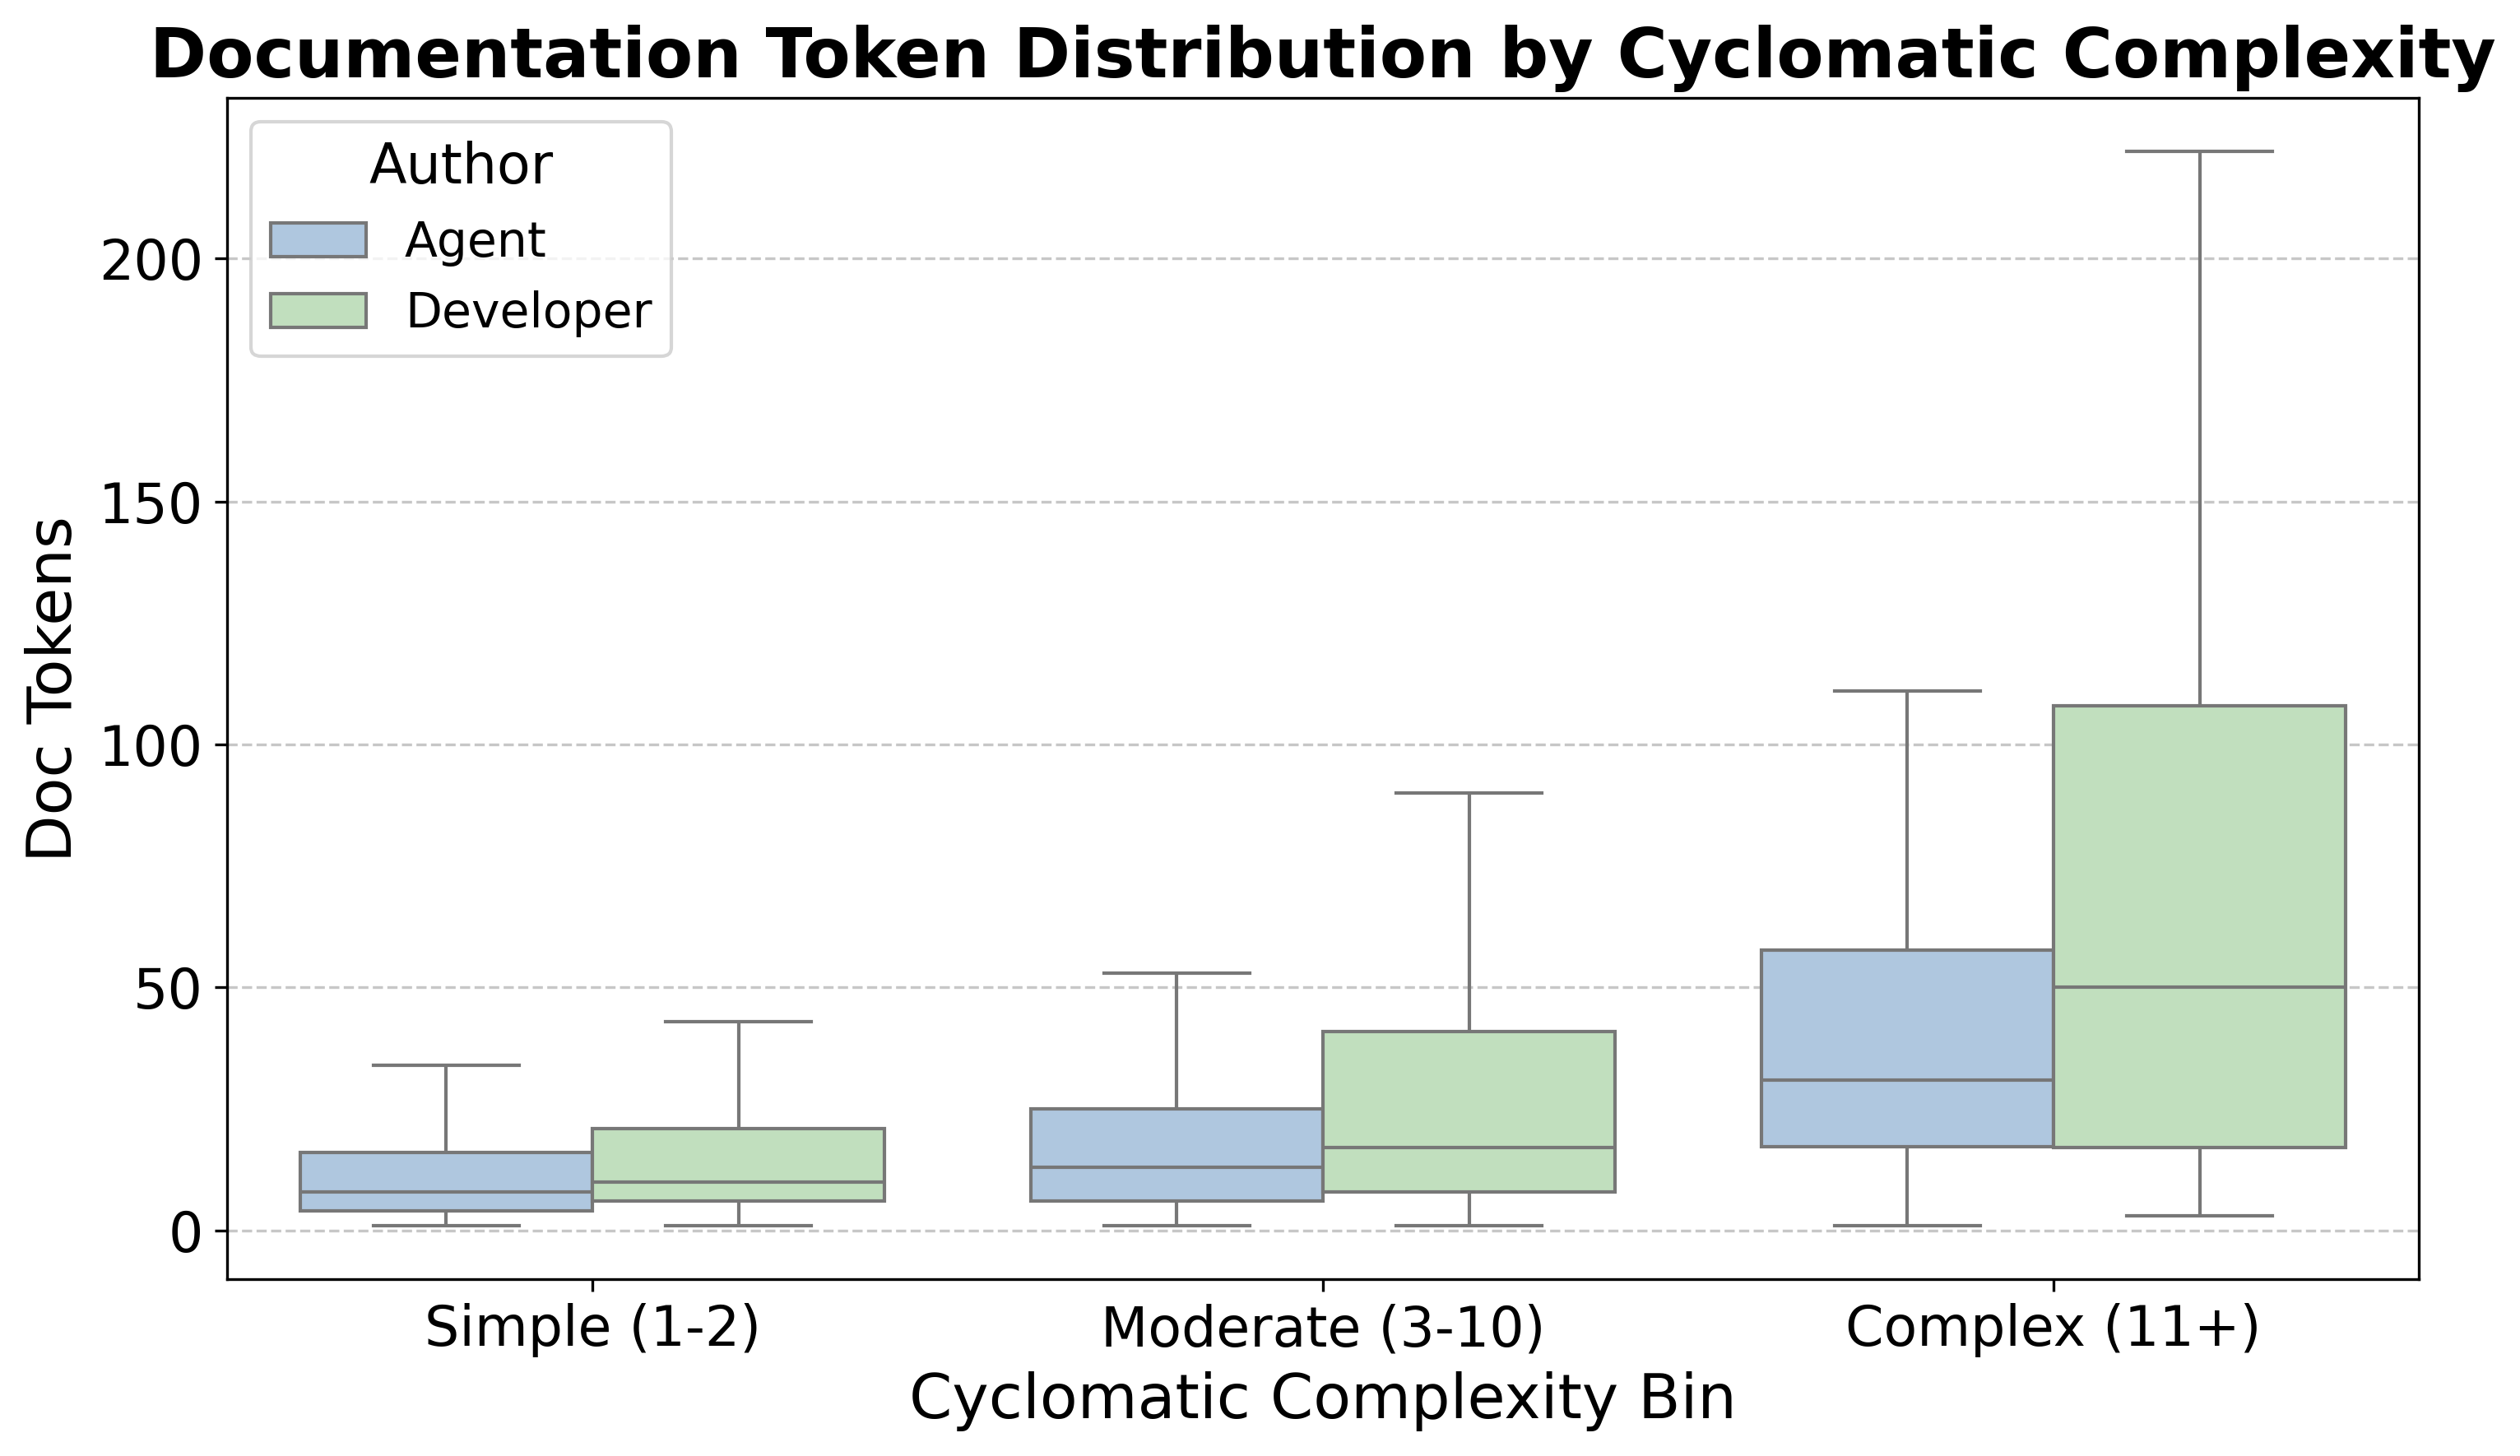


ANALYZING: sloc -> Effect on Doc Tokens
       group        sloc_bin  count        mean  median     p75    p90  \
0      Agent     Short (<10)   1626   10.362854     7.0   13.00   22.0   
1      Agent  Medium (11-50)   1814   19.680265    15.0   26.00   41.0   
2      Agent      Long (51+)    213   55.835681    37.0   76.00  106.4   
3  Developer     Short (<10)   1205   28.975934    10.0   20.00   38.6   
4  Developer  Medium (11-50)    880   31.103409    15.0   36.00   68.0   
5  Developer      Long (51+)    146  107.431507    54.0  109.75  261.5   

   n_p75_plus  n_p90_plus  
0         414         175  
1         464         189  
2          55          22  
3         303         121  
4         223          90  
5          37          15  


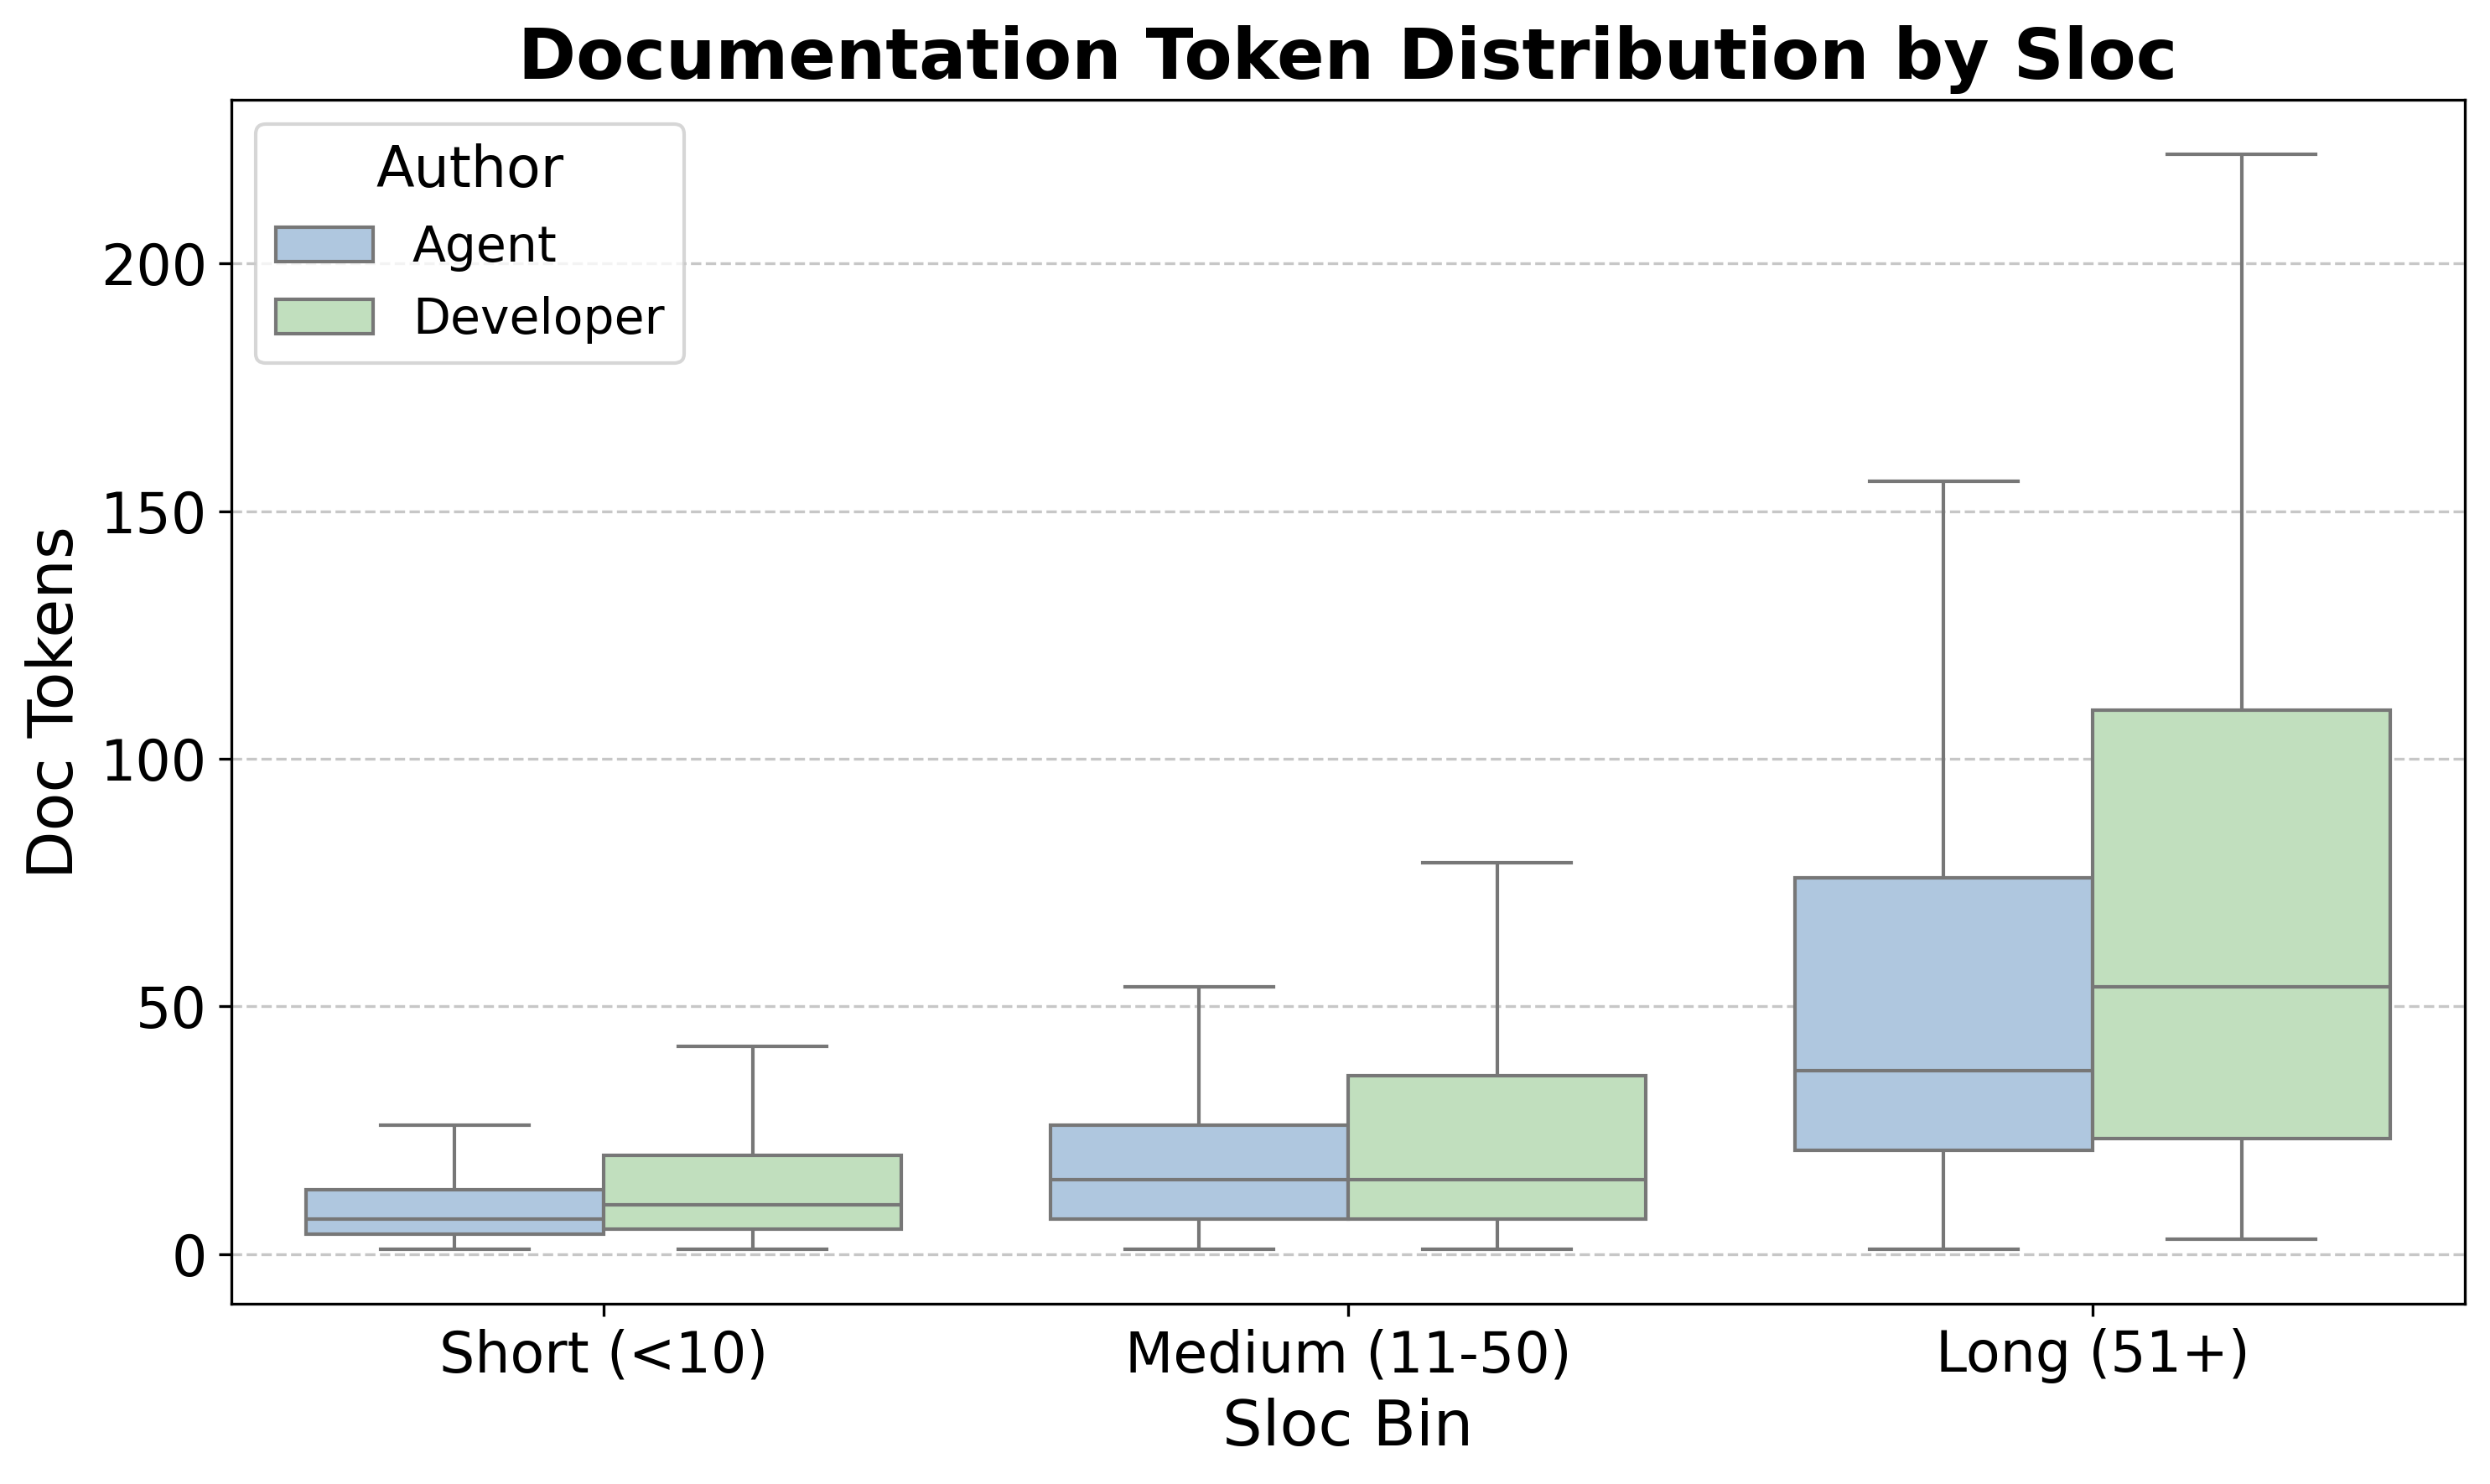


ANALYZING: semgrep_findings_count -> Effect on Doc Tokens
       group semgrep_findings_count_bin  count        mean  median     p75  \
0      Agent                  Clean (0)   3579   17.531154    11.0   22.00   
1      Agent           Low Issues (1-2)     58   22.172414     9.0   20.00   
2      Agent           High Issues (3+)     16   25.812500    22.0   33.25   
3  Developer                  Clean (0)   2159   28.654006    12.0   28.00   
4  Developer           Low Issues (1-2)     56  271.571429     9.0  780.00   
5  Developer           High Issues (3+)     16   56.250000    35.0   54.00   

     p90  n_p75_plus  n_p90_plus  
0   38.0         898         364  
1   68.0          16           7  
2   43.5           4           2  
3   58.2         556         216  
4  780.0          19          19  
5  141.0           4           2  


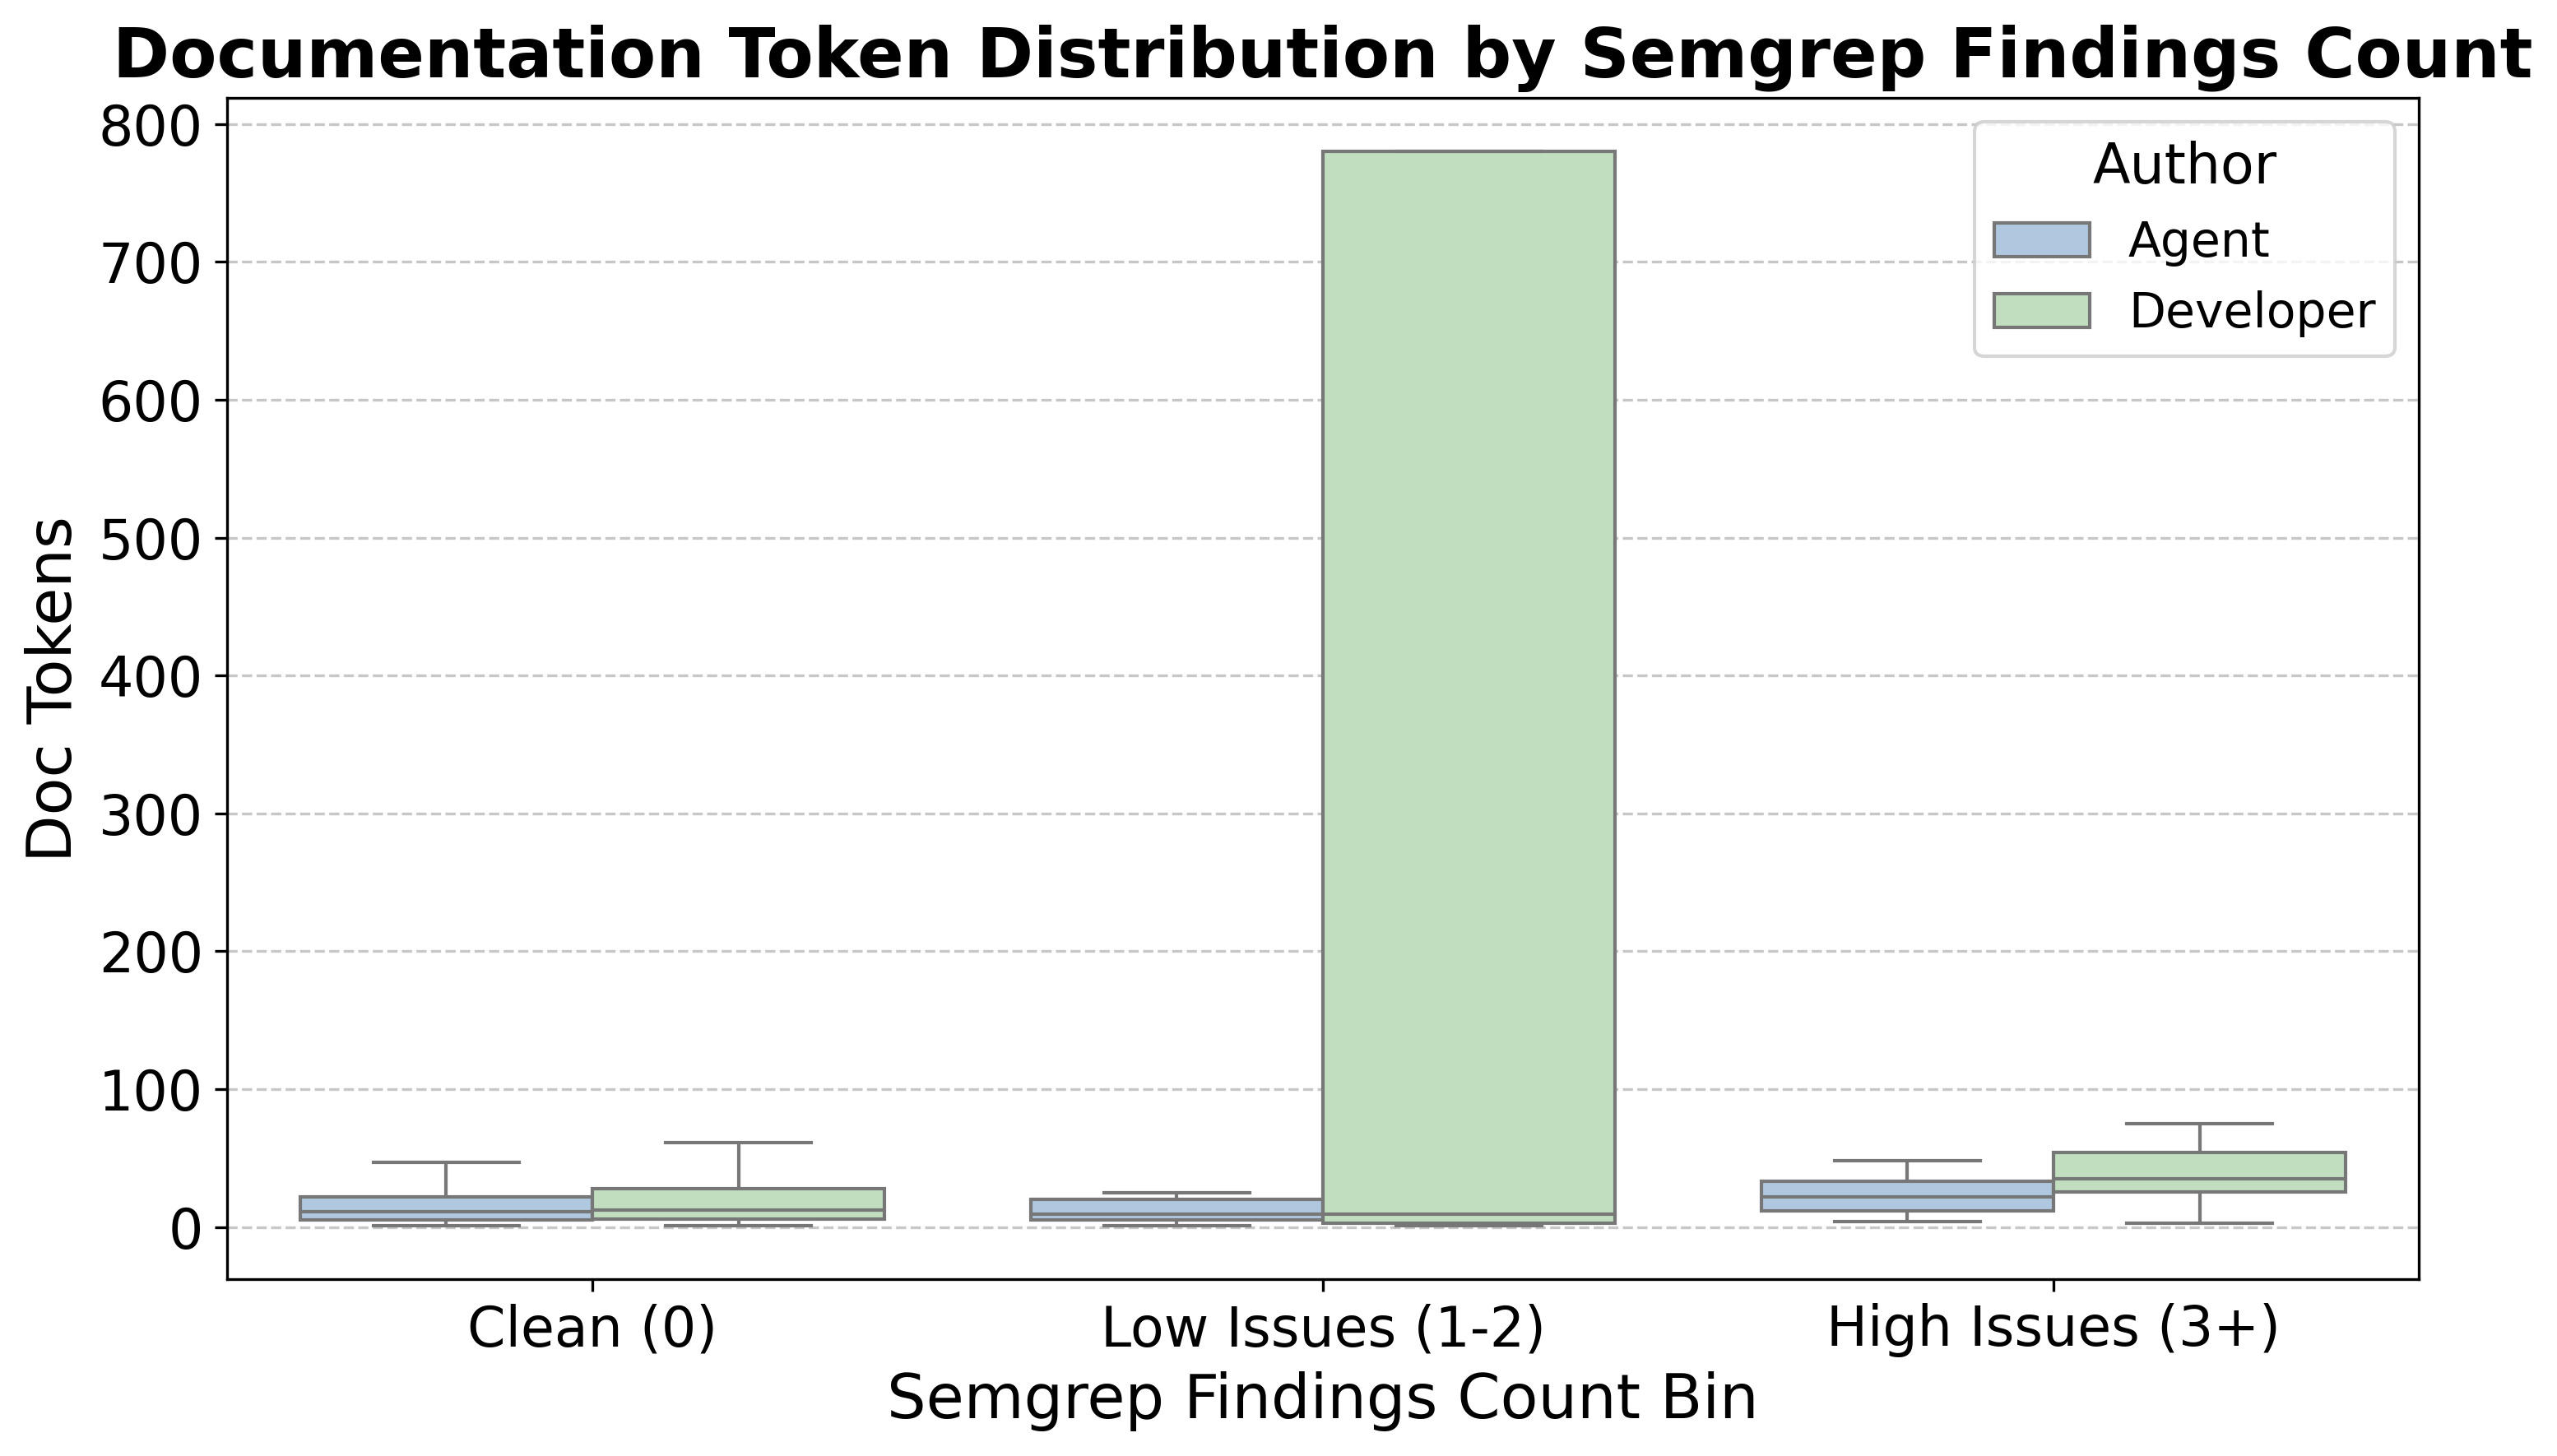

--- INSPECTING 0 OUTLIER DOCUMENTS ---

Are all 0 documents identical? False


In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = df[~df['file_path'].str.contains(r'\.next/', na=False)]
def tokenize(text):
    if not text or pd.isna(text):
        return []
    return re.findall(r"[A-Za-z_][A-Za-z0-9_]*", text.lower())
def get_effect_size_label(r):
    """Standard interpretation for Rank-Biserial Correlation."""
    abs_r = abs(r)
    if abs_r < 0.1: return "Negligible"
    if abs_r < 0.3: return "Small"
    if abs_r < 0.5: return "Medium"
    return "Large"
# 1. Pre-calculate doc_tokens
df['doc_tokens'] = df['doc_text'].apply(lambda x: len(tokenize(x)))
df['group'] = df['group'].map({'human': 'Developer', 'agent': 'Agent'})
# 2. Define Metric Bins (Tailored to the scale of each metric)
# Adjust these thresholds based on your data distribution!
metric_configs = {
    'cyclomatic_complexity': {
        'bins': [0, 2, 10, float('inf')],
        'labels': ['Simple (1-2)', 'Moderate (3-10)', 'Complex (11+)']
    },
    'sloc': {
        'bins': [0, 10, 50, float('inf')],
        'labels': ['Short (<10)', 'Medium (11-50)', 'Long (51+)']
    },
    'semgrep_findings_count': {
        'bins': [-1, 0, 2, float('inf')],
        'labels': ['Clean (0)', 'Low Issues (1-2)', 'High Issues (3+)']
    }
}

# 3. Analysis Loop
results = []

for metric, config in metric_configs.items():
    print(f"\n{'='*40}")
    print(f"ANALYZING: {metric} -> Effect on Doc Tokens")
    print(f"{'='*40}")
    
    # Create the bin for this specific metric
    bin_col = f"{metric}_bin"
    df[bin_col] = pd.cut(df[metric], bins=config['bins'], labels=config['labels'])

 
    

    
    summary = df.groupby(['group', bin_col], observed=True)['doc_tokens'].agg(
        count='count',
        mean='mean',
        median='median',
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        # p99=lambda x: x.quantile(0.99),
        # This counts how many functions actually sit in the "Top 10%" bracket
        n_p75_plus=lambda x: (x >= x.quantile(0.75)).sum(),
        n_p90_plus=lambda x: (x >= x.quantile(0.90)).sum(),
        # This counts how many functions are in the "Top 1%" bracket
        # n_p99_plus=lambda x: (x >= x.quantile(0.99)).sum()
    ).reset_index()
   

    

    print(summary)

    # 4. Visualization
    df_plot = df.dropna(subset=[bin_col, 'doc_tokens', 'group'])

    df_plot[bin_col] = pd.Categorical(
        df_plot[bin_col],
        categories=config['labels'],
        ordered=True
    )
        # REMOVE TOP 5% OUTLIERS (global across all bins/groups)
    cap = df_plot['doc_tokens']#.quantile(0.98)
    df_plot = df_plot[df_plot['doc_tokens'] <= cap]
    plt.figure(figsize=(10, 6), dpi=300)

    ax = sns.boxplot(
        data=df_plot,
        x=bin_col,
        y='doc_tokens',
        showfliers=False,
        hue='group',
        palette={"Agent": "#A7C7E7", "Developer": "#BDE5B8"}
    )

    plt.title(
        f"Documentation Token Distribution by {metric.replace('_', ' ').title()}",
        fontsize=20,
        fontweight='bold'
    )
    plt.ylabel("Doc Tokens", fontsize=18)
    plt.xlabel(f"{metric.replace('_', ' ').title()} Bin", fontsize=18)

    # 🔥 tick label fonts (THIS is what you were missing before)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    # 🔥 legend font control
    plt.legend(title="Author", fontsize=14, title_fontsize=16)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
# 1. Identify the threshold for the 'Low Issues' group from your summary
# (Based on your last output, we know this is 10,282)
target_bin = 'Low Issues (1-2)'
target_group = 'Agent'
p90_threshold = 10282

# 2. Filter the original dataframe for these specific outliers
outliers_df = df[
    (df['group'] == target_group) & 
    (df['semgrep_findings_count_bin'] == target_bin) & 
    (df['doc_tokens'] >= p90_threshold)
]

print(f"--- INSPECTING {len(outliers_df)} OUTLIER DOCUMENTS ---")

# 3. Print a sample of the text for the first 5 outliers to check for similarity
for i, (idx, row) in enumerate(outliers_df.head(5).iterrows()):
    text_snippet = str(row['doc_text'])[:500] # Take first 500 chars
    print(f"\n--- Outlier #{i+1} (Index: {idx}) ---")
    print(f"Token Count: {row['doc_tokens']}")
    print(f"Snippet: {text_snippet}...")
    print("-" * 30)

# 4. PRO TIP: Check if they are EXACTLY the same
is_identical = outliers_df['doc_text'].nunique() == 1
print(f"\nAre all {len(outliers_df)} documents identical? {is_identical}")


In [4]:
for metric, config in metric_configs.items():
    print(f"\n{'='*70}")
    print(f"ANALYZING: {metric}")
    print(f"{'='*70}")
    
    bin_col = f"{metric}_bin"
    df[bin_col] = pd.cut(df[metric], bins=config['bins'], labels=config['labels'])

    for label in config['labels']:
        subset = df[df[bin_col] == label]
        devs = subset[subset['group'] == 'Developer']['doc_tokens'].dropna()
        agents = subset[subset['group'] == 'Agent']['doc_tokens'].dropna()
        
        n1, n2 = len(devs), len(agents)
        
        if n1 > 5 and n2 > 5:
            # Mann-Whitney U Test
            u_stat, p_val = mannwhitneyu(devs, agents, alternative='two-sided')
            
            # Rank-Biserial Correlation Calculation
            # Formula: 1 - (2 * U / (n1 * n2))
            r_rb = 1 - (2 * u_stat / (n1 * n2))
            
            effect_label = get_effect_size_label(r_rb)
            sig_star = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""

            print(f"[{label}]")
            print(f"  Samples: Dev={n1}, Agent={n2}")
            print(f"  Stats:   p-val={p_val:.4f} {sig_star}")
            print(f"  Effect:  r_rb={r_rb:.3f} ({effect_label})")
            print("-" * 30)
        else:
            print(f"[{label}] Insufficient data (n < 5)")


ANALYZING: cyclomatic_complexity
[Simple (1-2)]
  Samples: Dev=1444, Agent=2041
  Stats:   p-val=0.0000 ***
  Effect:  r_rb=-0.146 (Small)
------------------------------
[Moderate (3-10)]
  Samples: Dev=644, Agent=1350
  Stats:   p-val=0.0000 ***
  Effect:  r_rb=-0.151 (Small)
------------------------------
[Complex (11+)]
  Samples: Dev=143, Agent=262
  Stats:   p-val=0.0011 **
  Effect:  r_rb=-0.196 (Small)
------------------------------

ANALYZING: sloc
[Short (<10)]
  Samples: Dev=1205, Agent=1626
  Stats:   p-val=0.0000 ***
  Effect:  r_rb=-0.233 (Small)
------------------------------
[Medium (11-50)]
  Samples: Dev=880, Agent=1814
  Stats:   p-val=0.0049 **
  Effect:  r_rb=-0.067 (Negligible)
------------------------------
[Long (51+)]
  Samples: Dev=146, Agent=213
  Stats:   p-val=0.0065 **
  Effect:  r_rb=-0.169 (Small)
------------------------------

ANALYZING: semgrep_findings_count
[Clean (0)]
  Samples: Dev=2159, Agent=3579
  Stats:   p-val=0.0000 ***
  Effect:  r_rb=-0.10

In [5]:
correlation_results = df.groupby('group')[['doc_tokens', 'cyclomatic_complexity', 'sloc', 'semgrep_findings_count']].corr(method='spearman')
print('spearman results')
print(correlation_results)

spearman results
                                  doc_tokens  cyclomatic_complexity      sloc  \
group                                                                           
Agent     doc_tokens                1.000000               0.320006  0.463255   
          cyclomatic_complexity     0.320006               1.000000  0.641885   
          sloc                      0.463255               0.641885  1.000000   
          semgrep_findings_count    0.018114               0.070073  0.086745   
Developer doc_tokens                1.000000               0.285562  0.281000   
          cyclomatic_complexity     0.285562               1.000000  0.674818   
          sloc                      0.281000               0.674818  1.000000   
          semgrep_findings_count    0.029586               0.087810  0.005602   

                                  semgrep_findings_count  
group                                                     
Agent     doc_tokens                            0.0181


REGRESSION COMPARISON: cyclomatic_complexity vs Doc Tokens
Bin: Clean (0) | p: 0.0000 | r: 0.109 (Small)
Bin: Low Issues (1-2) | p: 0.9635 | r: 0.005 (Negligible)
Bin: High Issues (3+) | p: 0.1310 | r: 0.316 (Medium)

[cyclomatic_complexity | Agent] ERROR COMPARISON
OLS   -> RMSE: 0.8335
QR    -> RMSE: 0.8374

[cyclomatic_complexity | Developer] ERROR COMPARISON
OLS   -> RMSE: 1.0429
QR    -> RMSE: 1.0491

REGRESSION COMPARISON: sloc vs Doc Tokens
Bin: Clean (0) | p: 0.0000 | r: 0.109 (Small)
Bin: Low Issues (1-2) | p: 0.9635 | r: 0.005 (Negligible)
Bin: High Issues (3+) | p: 0.1310 | r: 0.316 (Medium)

[sloc | Agent] ERROR COMPARISON
OLS   -> RMSE: 0.7915
QR    -> RMSE: 0.7961

[sloc | Developer] ERROR COMPARISON
OLS   -> RMSE: 1.0606
QR    -> RMSE: 1.0657

FINAL REGRESSION COMPARISON TABLE:
                  Metric      Group  OLS_Slope  QR_Median_Slope    OLS_R2  \
0  cyclomatic_complexity      Agent   0.511315         0.610740  0.136306   
1  cyclomatic_complexity  Developer   0.5

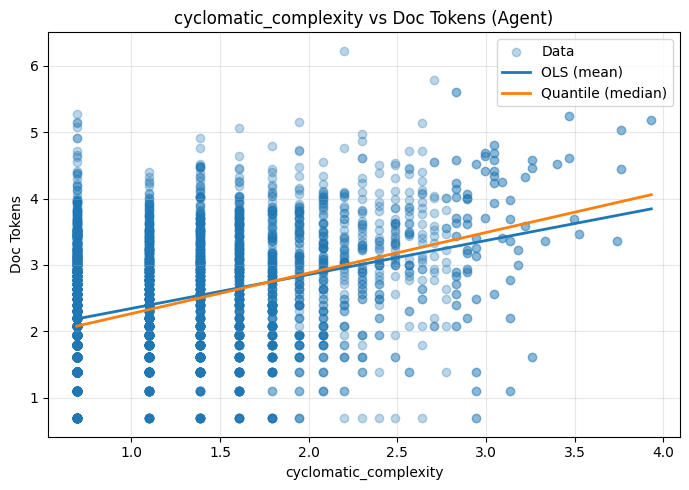

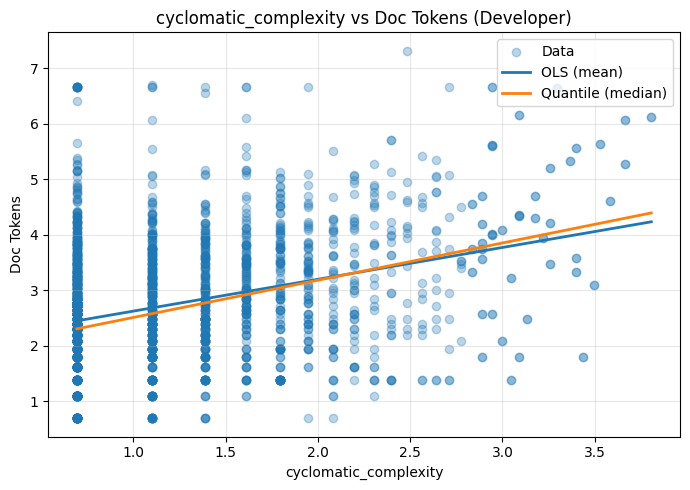

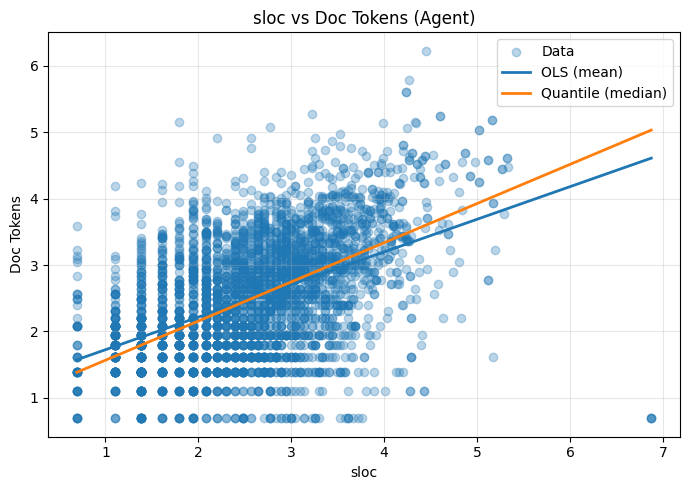

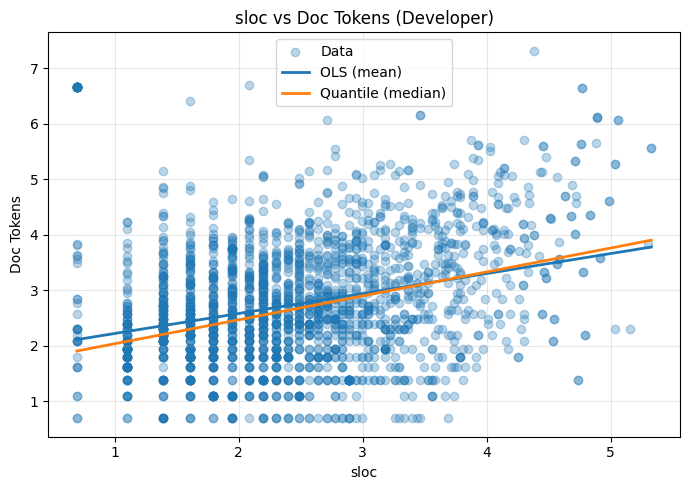

In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

regression_results = []

TAU = 0.5  # median regression

for metric in metric_configs.keys():
    if metric == 'semgrep_findings_count':
        continue
    print(f"\n{'='*70}")
    print(f"REGRESSION COMPARISON: {metric} vs Doc Tokens")
    print(f"{'='*70}")
    
    for bin_label in config['labels']:
        # Filter by bin first
        bin_data = df[df[bin_col] == bin_label]
        
        agent_tokens = bin_data[bin_data['group'] == 'Agent']['doc_tokens']
        dev_tokens = bin_data[bin_data['group'] == 'Developer']['doc_tokens']
        
        if len(agent_tokens) > 0 and len(dev_tokens) > 0:
            # Compare DOC TOKENS, not the metric itself
            u_stat, p_val = mannwhitneyu(agent_tokens, dev_tokens)
            
            # Calculate Rank-Biserial Correlation
            n_agent = len(agent_tokens)
            n_dev = len(dev_tokens)
            r_biserial = 1 - (2 * u_stat) / (n_agent * n_dev)
            
            print(f"Bin: {bin_label} | p: {p_val:.4f} | r: {r_biserial:.3f} ({get_effect_size_label(r_biserial)})")
    for group in df['group'].unique():
        
        subset = df[df['group'] == group].dropna(subset=[metric, 'doc_tokens'])
        
        if len(subset) < 5:
            print(f"Skipping {group}: insufficient data (N={len(subset)})")
            continue
        
        X = np.log1p(subset[metric].values)
        y = np.log1p(subset['doc_tokens'].values)


        # X = (subset[metric].values)
        # y = (subset['doc_tokens'].values)
        X_const = sm.add_constant(X)
        
        # =========================
        # 1. OLS REGRESSION
        # =========================
        ols_model = sm.OLS(y, X_const).fit()
        
        # =========================
        # 2. QUANTILE REGRESSION
        # =========================
        qr_model = sm.QuantReg(y, X_const).fit(q=TAU)
        

        
        # store results
        regression_results.append({
            'Metric': metric,
            'Group': group,
            'OLS_Slope': ols_model.params[1],
            'QR_Median_Slope': qr_model.params[1],
            'OLS_R2': ols_model.rsquared,
            'QR_Pseudo_R2': qr_model.prsquared,
            'N': len(subset)
        })
        # =========================
        # ERROR METRICS (IN-SAMPLE)
        # =========================

        ols_pred = ols_model.fittedvalues
        qr_pred = qr_model.predict(X_const)

        ols_rmse = np.sqrt(np.mean((y - ols_pred) ** 2))
        qr_rmse  = np.sqrt(np.mean((y - qr_pred) ** 2))

        print(f"\n[{metric} | {group}] ERROR COMPARISON")
        print(f"OLS   -> RMSE: {ols_rmse:.4f}")
        print(f"QR    -> RMSE: {qr_rmse:.4f}")
        # =========================
        # 3. PLOT
        # =========================
        plt.figure(figsize=(7, 5))
        
        # scatter
        plt.scatter(X, y, alpha=0.3, label="Data")
        
        # regression line range
        x_range = np.linspace(X.min(), X.max(), 100)
        X_line = sm.add_constant(x_range)
        
        # OLS line
        y_ols = ols_model.predict(X_line)
        plt.plot(x_range, y_ols, label="OLS (mean)", linewidth=2)
        
        # Quantile regression line
        y_qr = qr_model.predict(X_line)
        plt.plot(x_range, y_qr, label="Quantile (median)", linewidth=2)
        
        plt.title(f"{metric} vs Doc Tokens ({group})")
        plt.xlabel(metric)
        plt.ylabel("Doc Tokens")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        # plt.show()


# =========================
# SUMMARY TABLE
# =========================
reg_df = pd.DataFrame(regression_results)

print("\nFINAL REGRESSION COMPARISON TABLE:")
print(reg_df.sort_values(by=['Metric', 'Group']))




#not logged
# [cyclomatic_complexity | Agent] ERROR COMPARISON
# OLS   -> RMSE: 21.0926
# QR    -> RMSE: 21.8571

# [cyclomatic_complexity | Developer] ERROR COMPARISON
# OLS   -> RMSE: 90.3873
# QR    -> RMSE: 93.2462
# logged
# [cyclomatic_complexity | Agent] ERROR COMPARISON
# OLS   -> RMSE: 0.8335
# QR    -> RMSE: 0.8374

# [cyclomatic_complexity | Developer] ERROR COMPARISON
# OLS   -> RMSE: 1.0429
# QR    -> RMSE: 1.0491